In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/flights_final.csv", sep="\t", engine="python")

print("Flights:", len(df))
print("Columns:", len(df.columns))
df.head()

Flights: 1740
Columns: 48


,index,Date (MM/DD/YYYY),File,Gtype,Flight Time,Start Time,End Time,Landing,Start_Alt (ft MSL),Max Altitude (ft MSL/ft AGL),...,distance_traveled_during_window (miles),terrain_label_at_first_engine_event,avg_speed_during_pre_event_window (knots),std_dev_speed_during_pre_event_window (knots),avg_speed_during_post_event_window (knots),engine_run_times (s),height_gain_loss (ft),terrain_elev_at_first_engine_event (ft),dynamic_AGL_at_first_engine_event (ft),Engine_Start_Above_1000ft
0,1,03/12/2016,2016-03-12-CNI-21J-01.IGC,LAK17BFES,3:11:16,171318,202434,HOME,114,4967[4840],...,5.074177,"Open Forest, Other",56.65,10.03,60.78,"[60, 420, 60, 480, 300, 180, 60, 60, 420, 480,...","[154, 210, -89, 318, -1105, 125, -105, -181, 1...",125.31,2551.86,True
1,2,06/25/2024,46PGA9D1.IGC,Ventus3M18m,4:31:17,184736,231853,HOME,3694,12821[8793],...,7.166436,Herbaceous vegetation,74.73,10.91,63.95,[600],[3743],4088.87,678.19,False
2,4,03/11/2014,43BG8FH1.IGC,Unknown,4:45:38,164720,213258,HOME,121,3795[3700],...,0.101798,Herbaceous vegetation,3.70,9.04,54.48,[120],[1266],112.02,-102.18,False
3,5,06/17/2018,2018-06-17-CNI-27X-01.IGC,DG80015,2:47:12,183443,212155,HOME,5009,14642[8914],...,0.125748,Herbaceous vegetation,9.55,6.67,49.24,[420],[2890],5003.28,-55.77,False
4,6,08/15/2023,2023-08-15-CNI-25N-01.IGC,ASH31mi,3:43:47,173705,212052,HOME,948,9192[7336],...,0.070698,Shrubs,11.64,10.89,56.23,[360],[2234],932.41,-72.83,False


In [8]:
def confidence_score(row):

    score = 0

    # Higher confidence if engine starts above 1000 ft AGL
    if row["Engine_Start_Above_1000ft"] == True:
        score += 3

    # Higher confidence if aircraft returned HOME
    if row["Landing"] == "HOME":
        score += 2

    # Higher confidence if ENL detected the event
    if row["event_sensor"] == "ENL":
        score += 1

    # Higher confidence if circling occurred
    if row["is_circling_during_pre_event_window"] == True:
        score += 1

    return score

In [9]:
df["confidence_score"] = df.apply(
    confidence_score,
    axis=1
)

df["confidence_score"].describe()

count    1740.000000
mean        3.783908
std         1.514498
min         0.000000
25%         3.000000
50%         3.000000
75%         6.000000
max         7.000000
Name: confidence_score, dtype: float64

In [10]:
def classify(score):

    if score >= 6:
        return "High Confidence"

    elif score >= 3:
        return "Medium Confidence"

    else:
        return "Low Confidence"

In [11]:
df["confidence_class"] = df[
    "confidence_score"
].apply(classify)

df["confidence_class"].value_counts()

confidence_class
Medium Confidence    1166
High Confidence       436
Low Confidence        138
Name: count, dtype: int64

In [12]:
low_confidence = df[
    df["confidence_class"] == "Low Confidence"
]

low_confidence[
[
    "Date (MM/DD/YYYY)",
    "Gtype",
    "event_sensor",
    "Landing",
    "dynamic_AGL_at_first_engine_event (ft)",
    "terrain_label_at_first_engine_event"
]
].head(20)

,Date (MM/DD/YYYY),Gtype,event_sensor,Landing,dynamic_AGL_at_first_engine_event (ft),terrain_label_at_first_engine_event
7,06/21/2016,Unknown,ENL,LOUT,-42.49,Herbaceous vegetation
30,05/07/2018,JS-1-18m,MOP,HOME,-28.41,"Open Forest, Other"
47,06/03/2021,JonkersJS3,MOP,HOME,933.76,Herbaceous vegetation
98,06/21/2018,TEST,ENL,LOUT,-2.79,Herbaceous vegetation
116,04/26/2024,Ventus3FES,MOP,HOME,586.35,"Closed Forest, Other"
122,05/02/2018,JS-1-18m,MOP,HOME,-9.51,"Open Forest, Other"
126,03/17/2015,TAURUS,ENL,LOUT,41.42,Herbaceous vegetation
158,07/04/2018,DG808B/18m,ENL,LOUT,14.42,"Open Forest, Other"
192,08/20/2019,ASH31MI,ENL,LOUT,-93.62,Herbaceous vegetation
212,06/17/2018,ArcusM2pilot,ENL,LOUT,-57.58,Herbaceous vegetation


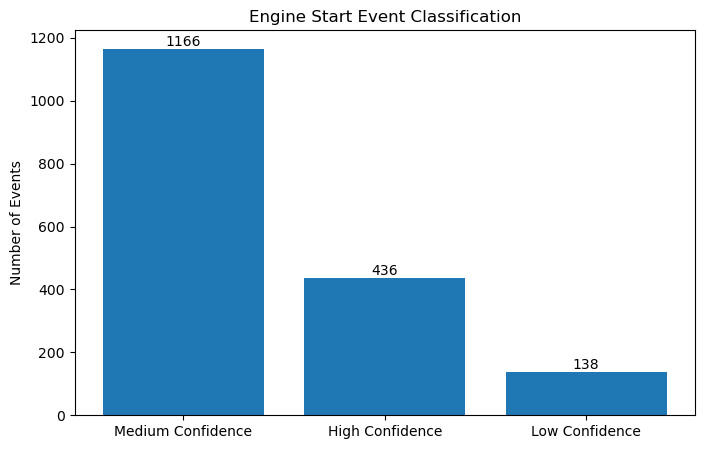

In [13]:
import matplotlib.pyplot as plt

confidence_counts = (
    df["confidence_class"]
    .value_counts()
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    confidence_counts.index,
    confidence_counts.values
)

plt.title(
    "Engine Start Event Classification"
)

plt.ylabel("Number of Events")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        int(bar.get_height()),
        ha="center"
    )

plt.show()